# Baseline Models: Ridge, Lasso, LightGBM, CatBoost

Бейзлайн-сравнение классических ML-моделей регрессии на 5-минутных барах.  
Горизонт прогнозирования — 12 баров (1 час). Метрики аналогичны основной модели 1D-CNN из `models.ipynb`.

**Подбор гиперпараметров:** Optuna (TPE sampler) + TimeSeriesSplit (без утечки из будущего)  
**Источник методологии:** [mlgu.ru/5446](https://mlgu.ru/5446/)  
**Модели:** Ridge, Lasso, LightGBM, CatBoost  
**Данные:** 5-минутные свечи MOEX (2020–2025)

In [15]:
# !pip install optuna lightgbm catboost

import numpy as np
import pandas as pd
from pathlib import Path
import time

from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

## 1. Параметры

In [16]:
# ══════════════════════════════════════════════
# ПАРАМЕТРЫ СТРАТЕГИИ
# ══════════════════════════════════════════════
HORIZON        = 12           # горизонт прогноза (баров)
TRAIN_YEARS    = 4            # лет на обучение
TEST_YEARS     = 2            # лет на тест
THRESHOLD      = 0.001        # порог для входа в позицию
COMMISSION     = 0.0003       # 0.03 % round-trip комиссия
BARS_PER_YEAR  = 252 * 78     # 5-минутные бары в году

# ══════════════════════════════════════════════
# ПАРАМЕТРЫ OPTUNA
# ══════════════════════════════════════════════
N_OPTUNA_TRIALS = 50          # кол-во итераций подбора (увеличить для точности)
N_CV_SPLITS     = 3           # кол-во фолдов TimeSeriesSplit
OPTUNA_SEED     = 42          # для воспроизводимости

# ══════════════════════════════════════════════
# ДАННЫЕ
# ══════════════════════════════════════════════
DATA_DIR       = Path("data")
START_DATE     = "2020-01-01"
END_DATE       = "2026-01-01"

TICKERS = ['MGNT', 'VTBR', 'TATN', 'YDEX', 'GLDRUB_TOM']

## 2. Утилиты: очистка данных

In [17]:
def fill_time_gaps(df: pd.DataFrame, interval_name: str = "5min") -> pd.DataFrame:
    """
    Вставляет пропущенные временные интервалы и заполняет их последним известным значением.
    Должна выполняться ПЕРЕД clean_market_data().
    """
    resample_map = {
        "5min": "5T", "15min": "15T", "1hour": "H", "1day": "D"
    }
    freq = resample_map.get(interval_name, "5T")
    df = df.copy()

    if 'DateTime' in df.columns:
        df['DateTime'] = pd.to_datetime(df['DateTime'])
        df = df.set_index('DateTime')
    elif not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame должен иметь колонку 'DateTime' или DatetimeIndex")

    df = df.sort_index()
    full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq)
    df = df.reindex(full_range)
    df.index.name = "DateTime"

    price_cols = ['Open', 'High', 'Low', 'Close']
    df[price_cols] = df[price_cols].ffill().bfill()
    if 'Volume' in df.columns:
        df['Volume'] = df['Volume'].fillna(0)

    return df.reset_index()


def clean_market_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Базовая очистка рыночных данных: замена нулевых цен на NaN + ffill/bfill.
    Выполняется ПОСЛЕ fill_time_gaps().
    """
    df = df.copy()
    if 'DateTime' in df.columns:
        df = df.set_index('DateTime').sort_index()

    cols_to_fix = ['Open', 'High', 'Low', 'Close']
    for col in cols_to_fix:
        if col in df.columns:
            df[col] = df[col].replace(0, pd.NA)

    df[cols_to_fix] = df[cols_to_fix].ffill().bfill()
    if 'Volume' in df.columns:
        df['Volume'] = df['Volume'].fillna(0)

    return df.reset_index() if 'DateTime' not in df.columns else df

## 3. Feature Engineering

In [18]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Создаёт фичи для регрессионных моделей:
    - Лагированные return и volume
    - Скользящая волатильность
    - RSI (14)
    - MACD
    """
    df = df.copy()
    close  = df["Close"]
    volume = df["Volume"]

    df["return"] = close.pct_change()

    for lag in [1, 2, 3, 5, 10, 20]:
        df[f"ret_lag_{lag}"]  = df["return"].shift(lag)
        df[f"vol_lag_{lag}"]  = volume.shift(lag)

    df["volatility"] = df["return"].rolling(20).std()

    delta = close.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    rs    = gain.rolling(14).mean() / loss.rolling(14).mean()
    df["RSI"] = 100 - (100 / (1 + rs))

    ema12 = close.ewm(span=12).mean()
    ema26 = close.ewm(span=26).mean()
    df["MACD"] = ema12 - ema26

    df = df.replace([np.inf, -np.inf], np.nan)
    return df.dropna()

## 4. Optuna: пространства поиска гиперпараметров

In [19]:
def create_model_from_trial(trial: optuna.Trial, model_name: str):
    """
    Для каждого trial Optuna сэмплирует гиперпараметры
    и возвращает (модель, uses_scaled_data: bool).
    """

    if model_name == "Ridge":
        alpha = trial.suggest_float("alpha", 1e-3, 100.0, log=True)
        return Ridge(alpha=alpha), True

    elif model_name == "Lasso":
        alpha = trial.suggest_float("alpha", 1e-6, 1e-1, log=True)
        return Lasso(alpha=alpha, max_iter=5000), True

    elif model_name == "LightGBM":
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 500, 4000, step=500),
            "learning_rate":     trial.suggest_float("learning_rate", 0.001, 0.1, log=True),
            "max_depth":         trial.suggest_int("max_depth", 2, 6),
            "num_leaves":        trial.suggest_int("num_leaves", 4, 31),
            "min_child_samples": trial.suggest_int("min_child_samples", 20, 300),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.2, 0.8),
            "subsample":         trial.suggest_float("subsample", 0.2, 0.8),
            "reg_alpha":         trial.suggest_float("reg_alpha", 0.01, 10.0, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 0.01, 10.0, log=True),
            "random_state":      42,
            "verbosity":         -1,
        }
        return LGBMRegressor(**params), False

    elif model_name == "CatBoost":
        params = {
            "iterations":          trial.suggest_int("iterations", 500, 4000, step=500),
            "learning_rate":       trial.suggest_float("learning_rate", 0.001, 0.1, log=True),
            "depth":               trial.suggest_int("depth", 2, 6),
            "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 0.1, 10.0, log=True),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
            "random_strength":     trial.suggest_float("random_strength", 0.01, 10.0, log=True),
            "verbose":             0,
            "random_state":        42,
        }
        return CatBoostRegressor(**params), False

    else:
        raise ValueError(f"Unknown model: {model_name}")

## 5. Optuna objective + подбор

In [20]:
def optimize_model(model_name: str,
                   X_train: np.ndarray, y_train: np.ndarray,
                   X_train_scaled: np.ndarray,
                   n_trials: int = N_OPTUNA_TRIALS,
                   n_splits: int = N_CV_SPLITS) -> tuple:
    """
    Подбирает гиперпараметры через Optuna + TimeSeriesSplit.
    Минимизирует RMSE на валидационных фолдах.
    Возвращает (best_params, best_cv_rmse).
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)

    def objective(trial):
        model, uses_scaled = create_model_from_trial(trial, model_name)
        X = X_train_scaled if uses_scaled else X_train

        rmse_scores = []
        for train_idx, val_idx in tscv.split(X):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            # Свежая модель для каждого фолда
            model_cv, _ = create_model_from_trial(trial, model_name)
            model_cv.fit(X_tr, y_tr)
            y_pred = model_cv.predict(X_val)

            rmse = np.sqrt(mean_squared_error(y_val, y_pred))
            rmse_scores.append(rmse)

        return np.mean(rmse_scores)

    sampler = optuna.samplers.TPESampler(seed=OPTUNA_SEED)
    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    return study.best_params, study.best_value

In [21]:
def build_best_model(model_name: str, best_params: dict):
    """
    Создаёт финальную модель с лучшими гиперпараметрами.
    Возвращает (model, uses_scaled_data).
    """
    if model_name == "Ridge":
        return Ridge(**best_params), True

    elif model_name == "Lasso":
        return Lasso(**best_params, max_iter=5000), True

    elif model_name == "LightGBM":
        return LGBMRegressor(**best_params, random_state=42, verbosity=-1), False

    elif model_name == "CatBoost":
        return CatBoostRegressor(**best_params, verbose=0, random_state=42), False

    else:
        raise ValueError(f"Unknown model: {model_name}")

## 6. Бэктест + метрики

In [22]:
def run_backtest(y_pred: np.ndarray, prices: np.ndarray,
                 horizon: int = HORIZON,
                 threshold: float = THRESHOLD,
                 commission: float = COMMISSION) -> dict:
    """
    Бэктест: фиксированный holding period = horizon баров.
    Вход в позицию, если |pred| > threshold.
    """
    trades = []
    equity = [1.0]
    position_open = False
    entry_price = 0.0
    entry_idx = 0

    for i in range(len(y_pred)):
        pred  = y_pred[i]
        price = prices[i]

        if position_open and (i >= entry_idx + horizon or i == len(y_pred) - 1):
            exit_price = price
            ret = (exit_price - entry_price) / entry_price - commission * 2
            equity.append(equity[-1] * (1 + ret))
            trades.append(ret)
            position_open = False

        if not position_open:
            if pred > threshold:
                position_open = True
                entry_price = price * (1 + commission)
                entry_idx = i
            elif pred < -threshold:
                position_open = True
                entry_price = price * (1 - commission)
                entry_idx = i
        else:
            equity.append(equity[-1])

    equity = np.array(equity)
    returns_eq = np.diff(equity) / equity[:-1]

    if trades:
        pnls = np.array(trades)
        n = len(pnls)
        win_rate      = (pnls > 0).mean() * 100
        total_return  = (equity[-1] - 1) * 100
        avg_trade     = pnls.mean() * 100
        gross_profit  = pnls[pnls > 0].sum()
        gross_loss    = abs(pnls[pnls < 0].sum())
        profit_factor = gross_profit / gross_loss if gross_loss != 0 else float('inf')
        avg_win  = pnls[pnls > 0].mean() if (pnls > 0).any() else 0
        avg_loss_val = abs(pnls[pnls < 0].mean()) if (pnls < 0).any() else 0
        avg_rr   = avg_win / avg_loss_val if avg_loss_val != 0 else float('inf')
        sharpe = (np.mean(returns_eq) / np.std(returns_eq) * np.sqrt(BARS_PER_YEAR)
                  if np.std(returns_eq) > 0 else 0)
        se  = pnls.std() / np.sqrt(n) if n > 1 else 0
        mde = 2.8 * se * 100
        stat_sig = abs(pnls.mean() * 100) > mde
    else:
        n = 0
        win_rate = total_return = avg_trade = 0
        profit_factor = avg_rr = sharpe = mde = 0
        stat_sig = False

    return {
        "n_trades": n, "win_rate": win_rate, "total_return": total_return,
        "avg_trade": avg_trade, "profit_factor": profit_factor, "avg_rr": avg_rr,
        "sharpe": sharpe, "mde": mde, "stat_sig": stat_sig, "equity": equity,
    }

In [23]:
def print_report(name: str, ticker: str, mae: float, rmse: float,
                 metrics: dict, test_days: int, best_params: dict,
                 cv_rmse: float, tune_time: float) -> None:
    """Форматированный вывод результатов."""
    print("\n══════════════════════════════════════════════════════════════════════")
    print(f"ИТОГО ПО СТРАТЕГИИ -> {name} | {ticker} (горизонт {HORIZON} баров)")
    print("══════════════════════════════════════════════════════════════════════")
    print(f"Лучшие гиперпараметры (Optuna, {N_OPTUNA_TRIALS} trials):")
    for k, v in best_params.items():
        val_str = f"{v:.6f}" if isinstance(v, float) else str(v)
        print(f"  {k:25s} = {val_str}")
    print(f"  CV RMSE (TimeSeriesSplit): {cv_rmse:.6f}")
    print(f"  Время подбора:            {tune_time:.1f} сек")
    print("----------------------------------------------------------------------")
    print(f"Test MAE / RMSE:       {mae:.6f} / {rmse:.6f}")
    print(f"Всего сделок:          {metrics['n_trades']}")
    print(f"Win Rate:              {metrics['win_rate']:.1f} %")
    print(f"Общая доходность:      {metrics['total_return']:.1f} %")
    print(f"Средняя сделка:        {metrics['avg_trade']:.4f} %")
    print(f"Profit Factor:         {metrics['profit_factor']:.2f}")
    print(f"Average RR Ratio:      {metrics['avg_rr']:.2f}")
    print(f"Sharpe Ratio:          {metrics['sharpe']:.2f}")
    print(f"MDE (мин. значимый эффект): {metrics['mde']:.2f} %")
    print(f"Статистическая значимость: {'ДА' if metrics['stat_sig'] else 'НЕТ (шум)'}")
    print("----------------------------------------------------------------------")
    print(f"Период теста:          {test_days} дней = {round(test_days / 30.4375, 1)} мес.")
    print(f"Средний holding period: {HORIZON} баров (фиксированный)")
    print("══════════════════════════════════════════════════════════════════════")

## 7. Основной пайплайн: один тикер

In [24]:
MODEL_NAMES = ["Ridge", "Lasso", "LightGBM", "CatBoost"]


def run_baseline_for_ticker(ticker: str, verbose: bool = True) -> list:
    """
    Полный пайплайн для одного тикера:
      1. Загрузка и очистка
      2. Feature engineering + target
      3. Train / Test split (4 + 2 года)
      4. Optuna: подбор гиперпараметров на train (TimeSeriesSplit)
      5. Переобучение лучшей модели на всём train
      6. Предсказание на test -> бэктест -> метрики
    """
    # -- Загрузка --
    fpath = DATA_DIR / f"{ticker}_5min.parquet"
    if not fpath.exists():
        print(f"WARNING: Файл {fpath} не найден — пропускаю {ticker}")
        return []

    df = pd.read_parquet(fpath)
    df = df[(df['DateTime'] >= START_DATE) & (df['DateTime'] < END_DATE)]
    df = fill_time_gaps(df)
    df = clean_market_data(df)

    if 'DateTime' not in df.columns:
        df = df.reset_index()
    df["DateTime"] = pd.to_datetime(df["DateTime"])
    df = df.sort_values("DateTime").reset_index(drop=True)

    if verbose:
        print(f"\n{'#'*70}")
        print(f"# ТИКЕР: {ticker}  |  строк: {len(df):,}")
        print(f"{'#'*70}")

    # -- Фичи + таргет --
    df = add_features(df)
    df["target"] = df["Close"].pct_change(HORIZON).shift(-HORIZON)
    df = df.dropna()

    # -- Time split --
    start_date = df["DateTime"].min()
    train_end  = start_date + pd.DateOffset(years=TRAIN_YEARS)
    test_end   = train_end  + pd.DateOffset(years=TEST_YEARS)

    train_df = df[df["DateTime"] < train_end].copy()
    test_df  = df[(df["DateTime"] >= train_end) & (df["DateTime"] < test_end)].copy()

    if len(train_df) < 1000 or len(test_df) < 100:
        print(f"WARNING: Недостаточно данных для {ticker} "
              f"(train={len(train_df)}, test={len(test_df)})")
        return []

    if verbose:
        print(f"Train: {train_df['DateTime'].min().date()} — "
              f"{train_df['DateTime'].max().date()}  ({len(train_df):,} строк)")
        print(f"Test:  {test_df['DateTime'].min().date()} — "
              f"{test_df['DateTime'].max().date()}   ({len(test_df):,} строк)")

    test_days = (test_df['DateTime'].max() - test_df['DateTime'].min()).days

    # -- X / y --
    feature_cols = [c for c in df.columns if c not in ["DateTime", "target"]]

    X_train_raw = train_df[feature_cols].values
    y_train_arr = train_df["target"].values
    X_test_raw  = test_df[feature_cols].values
    y_test_arr  = test_df["target"].values
    prices_test = test_df["Close"].values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled  = scaler.transform(X_test_raw)

    # -- Перебор моделей --
    results_rows = []

    for model_name in MODEL_NAMES:
        if verbose:
            print(f"\n{'='*20} {model_name}: Optuna ({N_OPTUNA_TRIALS} trials) {'='*20}")

        # 1) Подбор гиперпараметров
        t0 = time.time()
        best_params, cv_rmse = optimize_model(
            model_name, X_train_raw, y_train_arr, X_train_scaled
        )
        tune_time = time.time() - t0

        if verbose:
            print(f"  -> Best CV RMSE: {cv_rmse:.6f}  ({tune_time:.1f} сек)")

        # 2) Финальное обучение на ВСЁМ train
        final_model, uses_scaled = build_best_model(model_name, best_params)
        X_fit  = X_train_scaled if uses_scaled else X_train_raw
        X_pred = X_test_scaled  if uses_scaled else X_test_raw

        final_model.fit(X_fit, y_train_arr)
        y_pred = final_model.predict(X_pred)

        # 3) Ошибки прогноза на test
        mae  = mean_absolute_error(y_test_arr, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_arr, y_pred))

        # 4) Бэктест
        metrics = run_backtest(y_pred, prices_test)

        if verbose:
            print_report(model_name, ticker, mae, rmse,
                         metrics, test_days, best_params, cv_rmse, tune_time)

        # 5) Строка для сводки
        results_rows.append({
            "Ticker":         ticker,
            "Model":          model_name,
            "MAE":            mae,
            "RMSE":           rmse,
            "CV_RMSE":        cv_rmse,
            "Trades":         metrics["n_trades"],
            "Win Rate %":     round(metrics["win_rate"], 1),
            "Total Return %": round(metrics["total_return"], 2),
            "Avg Trade %":    round(metrics["avg_trade"], 4),
            "Profit Factor":  round(metrics["profit_factor"], 2),
            "Avg RR":         round(metrics["avg_rr"], 2),
            "Sharpe":         round(metrics["sharpe"], 2),
            "MDE %":          round(metrics["mde"], 2),
            "Stat Sig":       metrics["stat_sig"],
            "Tune Time (s)":  round(tune_time, 1),
            "Best Params":    str(best_params),
        })

    return results_rows

## 8. Запуск по всем тикерам

In [25]:
all_results = []

for ticker in TICKERS:
    rows = run_baseline_for_ticker(ticker, verbose=True)
    all_results.extend(rows)

print(f"\nВсе тикеры обработаны. Итого строк: {len(all_results)}")


######################################################################
# ТИКЕР: MGNT  |  строк: 524,652
######################################################################
Train: 2021-01-04 — 2025-01-04  (216,082 строк)
Test:  2025-01-04 — 2025-12-30   (83,349 строк)

==================== Ridge: Optuna (50 trials) ====================
  -> Best CV RMSE: 0.006704  (2.5 сек)

══════════════════════════════════════════════════════════════════════
ИТОГО ПО СТРАТЕГИИ -> Ridge | MGNT (горизонт 12 баров)
══════════════════════════════════════════════════════════════════════
Лучшие гиперпараметры (Optuna, 50 trials):
  alpha                     = 0.010935
  CV RMSE (TimeSeriesSplit): 0.006704
  Время подбора:            2.5 сек
----------------------------------------------------------------------
Test MAE / RMSE:       0.002555 / 0.003956
Всего сделок:          1440
Win Rate:              48.4 %
Общая доходность:      -41.8 %
Средняя сделка:        -0.0359 %
Profit Factor:         0.83
Av

## 9. Сводная таблица результатов

In [29]:
summary_df = pd.DataFrame(all_results)

if not summary_df.empty:
    display_cols = [c for c in summary_df.columns if c != 'Best Params']

    print("\n" + "=" * 100)
    print("СВОДНАЯ ТАБЛИЦА BASELINE-МОДЕЛЕЙ (с подбором гиперпараметров)")
    print("=" * 100)
    display(summary_df[display_cols].style
            .format({
                'MAE':            '{:.6f}',
                'RMSE':           '{:.6f}',
                'CV_RMSE':        '{:.6f}',
                'Total Return %': '{:.2f}',
                'Avg Trade %':    '{:.4f}',
                'Profit Factor':  '{:.2f}',
                'Avg RR':         '{:.2f}',
                'Sharpe':         '{:.2f}',
                'MDE %':          '{:.2f}',
            })
            .background_gradient(subset=['Total Return %', 'Sharpe'], cmap='RdYlGn')
    )
else:
    print("Нет результатов — проверьте наличие parquet-файлов в data/")


СВОДНАЯ ТАБЛИЦА BASELINE-МОДЕЛЕЙ (с подбором гиперпараметров)


,Ticker,Model,MAE,RMSE,CV_RMSE,Trades,Win Rate %,Total Return %,Avg Trade %,Profit Factor,Avg RR,Sharpe,MDE %,Stat Sig,Tune Time (s)
0,MGNT,Ridge,0.002555,0.003956,0.006704,1440,48.400000,-41.77,-0.0359,0.83,0.89,-2.51,0.04,False,2.500000
1,MGNT,Lasso,0.002533,0.003943,0.006717,406,43.800000,-22.65,-0.0603,0.81,1.04,-3.15,0.11,False,11.700000
2,MGNT,LightGBM,0.003363,0.004667,0.006709,4632,34.300000,-98.46,-0.0893,0.49,0.94,-9.29,0.02,True,409.600000
3,MGNT,CatBoost,0.003094,0.004528,0.006733,4375,33.700000,-98.31,-0.0925,0.47,0.93,-9.67,0.02,True,506.600000
4,VTBR,Ridge,0.002557,0.005751,0.006644,1767,45.100000,-62.98,-0.0505,0.80,0.97,-1.98,0.07,False,2.100000
5,VTBR,Lasso,0.002524,0.005705,0.006594,123,49.600000,-0.43,0.0150,1.03,1.05,0.30,0.50,False,4.000000
6,VTBR,LightGBM,0.002509,0.005697,0.006587,201,59.200000,-6.01,-0.0266,0.91,0.63,-1.17,0.18,False,339.000000
7,VTBR,CatBoost,0.002506,0.005710,0.006607,413,61.000000,-22.71,-0.0501,0.82,0.52,-1.40,0.20,False,613.900000
8,TATN,Ridge,0.002673,0.004337,0.006352,2616,45.000000,-73.61,-0.0494,0.77,0.94,-3.57,0.03,True,2.000000
9,TATN,Lasso,0.002670,0.004336,0.006363,1997,43.800000,-69.13,-0.0571,0.76,0.97,-3.86,0.04,True,60.200000


## 10. Лучшие гиперпараметры (для воспроизводимости)

In [30]:
if not summary_df.empty:
    print("\nЛучшие гиперпараметры по каждому (Ticker x Model):")
    print("-" * 80)
    for _, row in summary_df.iterrows():
        print(f"\n{row['Ticker']} | {row['Model']}  (CV RMSE: {row['CV_RMSE']:.6f})")
        print(f"  {row['Best Params']}")


Лучшие гиперпараметры по каждому (Ticker x Model):
--------------------------------------------------------------------------------

MGNT | Ridge  (CV RMSE: 0.006704)
  {'alpha': 0.010934508675626562}

MGNT | Lasso  (CV RMSE: 0.006717)
  {'alpha': 0.00010806039452072894}

MGNT | LightGBM  (CV RMSE: 0.006709)
  {'n_estimators': 2000, 'learning_rate': 0.013447662249174056, 'max_depth': 3, 'num_leaves': 22, 'min_child_samples': 177, 'colsample_bytree': 0.7360067021761001, 'subsample': 0.2669273249312648, 'reg_alpha': 4.514398416231702, 'reg_lambda': 0.024438956195631276}

MGNT | CatBoost  (CV RMSE: 0.006733)
  {'iterations': 500, 'learning_rate': 0.0019261017678149674, 'depth': 2, 'l2_leaf_reg': 2.479554845154804, 'bagging_temperature': 0.35888358405364595, 'random_strength': 1.9234995284690055}

VTBR | Ridge  (CV RMSE: 0.006644)
  {'alpha': 2.6997851039876517}

VTBR | Lasso  (CV RMSE: 0.006594)
  {'alpha': 0.0002763227054314771}

VTBR | LightGBM  (CV RMSE: 0.006587)
  {'n_estimators': 1

## 11. Агрегация: средние метрики по модели

In [32]:
if not summary_df.empty:
    agg_cols = ['Trades', 'Win Rate %', 'Total Return %', 'Avg Trade %',
                'Profit Factor', 'Avg RR', 'Sharpe', 'MDE %', 'Tune Time (s)']

    avg_by_model = summary_df.groupby('Model')[agg_cols].mean().round(3)
    avg_by_model = avg_by_model.sort_values('Sharpe', ascending=False)

    print("\n" + "=" * 100)
    print("СРЕДНИЕ МЕТРИКИ ПО МОДЕЛИ (across all tickers)")
    print("=" * 100)
    display(avg_by_model)


СРЕДНИЕ МЕТРИКИ ПО МОДЕЛИ (across all tickers)


,Trades,Win Rate %,Total Return %,Avg Trade %,Profit Factor,Avg RR,Sharpe,MDE %,Tune Time (s)
Model,,,,,,,,,
CatBoost,1154.0,52.52,-7.932,0.003,1.024,0.850,-1.158,0.114,482.22
Lasso,833.2,43.26,-20.424,-0.030,0.896,1.242,-1.734,0.282,18.68
Ridge,2200.8,45.72,-58.190,-0.042,0.796,0.942,-2.996,0.040,1.96
LightGBM,1550.6,46.76,-21.588,-0.040,0.824,0.892,-4.028,0.074,462.38


## 12. Визуализация: сравнительные bar-charts

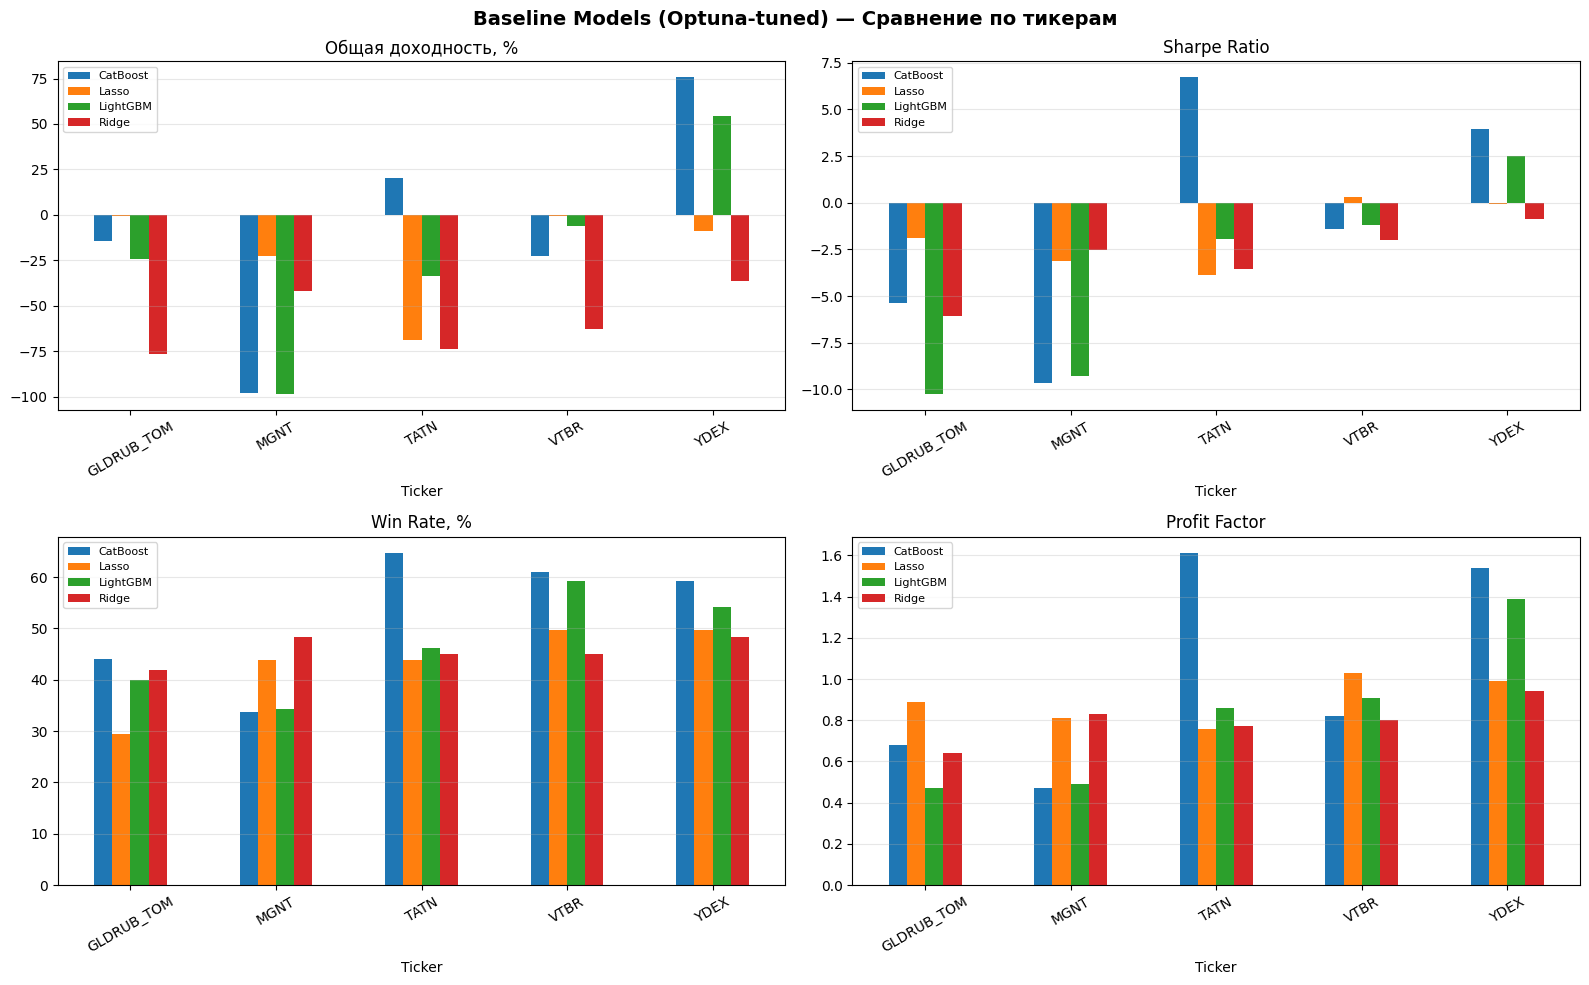

In [33]:
if not summary_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Baseline Models (Optuna-tuned) — Сравнение по тикерам',
                 fontsize=14, fontweight='bold')

    metrics_to_plot = [
        ('Total Return %', 'Общая доходность, %'),
        ('Sharpe',         'Sharpe Ratio'),
        ('Win Rate %',     'Win Rate, %'),
        ('Profit Factor',  'Profit Factor'),
    ]

    for ax, (col, title) in zip(axes.flat, metrics_to_plot):
        pivot = summary_df.pivot(index='Ticker', columns='Model', values=col)
        pivot.plot(kind='bar', ax=ax, rot=30)
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

## 13. Scatter: CV RMSE vs Test RMSE (переобучение?)

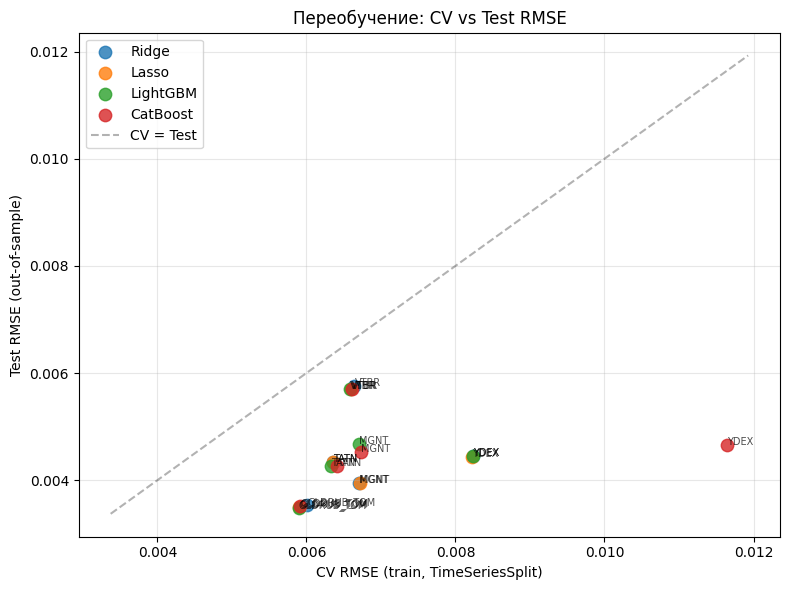

In [34]:
if not summary_df.empty:
    fig, ax = plt.subplots(figsize=(8, 6))

    for model_name in MODEL_NAMES:
        subset = summary_df[summary_df['Model'] == model_name]
        ax.scatter(subset['CV_RMSE'], subset['RMSE'],
                   label=model_name, s=80, alpha=0.8)
        for _, row in subset.iterrows():
            ax.annotate(row['Ticker'], (row['CV_RMSE'], row['RMSE']),
                        fontsize=7, alpha=0.7)

    # Диагональ
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', alpha=0.3, label='CV = Test')

    ax.set_xlabel('CV RMSE (train, TimeSeriesSplit)')
    ax.set_ylabel('Test RMSE (out-of-sample)')
    ax.set_title('Переобучение: CV vs Test RMSE')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 14. Экспорт результатов

In [35]:
if not summary_df.empty:
    out_path = DATA_DIR / "baseline_results_tuned.csv"
    summary_df.to_csv(out_path, index=False)
    print(f"Результаты сохранены: {out_path}")

Результаты сохранены: data/baseline_results_tuned.csv
